# Data Exploration & Preprocessing

This notebook explores the Amazon Cell Phones & Accessories dataset and summarizes the preprocessing steps used to construct the product dataset for the recommendation system.

The preprocessing pipeline includes product filtering, representative review selection, product document construction, and creation of a compact text representation for semantic retrieval.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 100)

PROCESSED_DIR = Path("../data/processed")

PRODUCT_FILE = PROCESSED_DIR / "products_ge50.parquet"
REVIEWS_FILE = PROCESSED_DIR / "representative_reviews.parquet"
DOCUMENT_FILE = PROCESSED_DIR / "product_documents.parquet"
EMBEDDING_FILE = PROCESSED_DIR / "product_documents_final.parquet"

## 1. Dataset Overview

The project uses product metadata and customer reviews from the Amazon Cell Phones & Accessories dataset.

The processed artifacts generated during preprocessing are loaded below for exploration and validation.

In [2]:
# Load processed datasets
products = pd.read_parquet(PRODUCT_FILE)
reviews = pd.read_parquet(REVIEWS_FILE)
documents = pd.read_parquet(DOCUMENT_FILE)
embedding_data = pd.read_parquet(EMBEDDING_FILE)

print("Products:", products.shape)
print("Representative reviews:", reviews.shape)
print("Product documents:", documents.shape)
print("Embedding data:", embedding_data.shape)

Products: (60889, 13)
Representative reviews: (304445, 9)
Product documents: (60889, 14)
Embedding data: (60889, 16)


## 2. Product Metadata

The product metadata contains information such as product title, category, ratings, price, features, and product identifiers.

In [3]:
products.head()

,parent_asin,main_category,title,average_rating,rating_number,features,description,price,store,categories,details,subtitle,review_count
0,1060697416,Cell Phones & Accessories,MHL/Micro-USB to HDMI High Speed Adapter! Fast Digital Conversion to HDMI Using The Official MHL...,3.7,223,[Converts the Galaxy Note 4 Micro USB Port to an HDMI output for playing back HD videos on a cap...,[MHL/Micro-USB to HDMI High Speed Adapter! Fast digital conversion to HDMI using the official MH...,None,BlastCase,"[Cell Phones & Accessories, Accessories]","{""Product Dimensions"": ""24 x 6 x 6 inches"", ""Item Weight"": ""0.353 ounces"", ""Item model number"": ...",NaN,141
1,120401325X,Cell Phones & Accessories,BY champper Leopard Home Button Sticker for Iphone 4g/4s Ipad2 Ipod (At&t Only) Jc064an + Free S...,4.1,123,[6 pcs in one pack],[6 pcs in one pack],None,ksshopping,"[Cell Phones & Accessories, Accessories, Maintenance, Upkeep & Repairs, Screen Protectors]","{""Package Dimensions"": ""0.1 x 0.1 x 0.1 inches"", ""Item Weight"": ""0.353 ounces"", ""Item model numb...",NaN,55
2,1395871035,Cell Phones & Accessories,"Freedi Car Non-slip Dash Grip Pad Mat Dashboard Magic Mounting Pad for Passport 9500ix, Escort, ...",3.4,72,[100% Brand New and High Quality Perfect item for home & car use Prevent your electric devices f...,[100% Brand New and High Quality Perfect item for home & car use Prevent your electric devices f...,None,Freedi,"[Cell Phones & Accessories, Accessories, Automobile Accessories, Cradles]","{""Product Dimensions"": ""5.31 x 2.95 x 0.08 inches"", ""Item Weight"": ""0.353 ounces"", ""Item model n...",NaN,51
3,1948701847,Cell Phones & Accessories,Trenro Micro USB to 30 pin Female/Male Charger Adapter compatible with Apple iPhone 4S/iPad /iPod,4.3,717,[100% brand new Micro USB Female to 30pin Male Charger Adapter Use this adapter to connect iPhon...,[100% brand new Micro USB Female to 30pin Male Charger Adapter Use this adapter to connect iPhon...,None,Trenro,"[Cell Phones & Accessories, Accessories]","{""Product Dimensions"": ""11.5 x 1.1 x 5.8 inches"", ""Item Weight"": ""0.02 Pounds"", ""Item model numb...",NaN,159
4,3056508193,Cell Phones & Accessories,Google Cardboard @ 45mm Focal Length Virtual Reality Google Cardboard with Printed Instructions ...,3.5,94,"[Instructions and Easy to Follow Numbered Tabs (WITH NFC) (Box Color), Easy to assemble. With Pr...",[GOOGLE CARDBOARD Newly Improved Virtual Reality Cardboard Kit with NFC Tag-Google Cardboard Exa...,None,Google Cardboard,"[Cell Phones & Accessories, Accessories, Virtual Reality (VR) Headsets]","{""Package Dimensions"": ""8.3 x 6.2 x 0.8 inches"", ""Item Weight"": ""0.353 ounces"", ""Item model numb...",NaN,85


In [4]:
products.info()

<class 'pandas.DataFrame'>
RangeIndex: 60889 entries, 0 to 60888
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   parent_asin     60889 non-null  str    
 1   main_category   59964 non-null  str    
 2   title           60889 non-null  str    
 3   average_rating  60889 non-null  float64
 4   rating_number   60889 non-null  int64  
 5   features        60889 non-null  object 
 6   description     60889 non-null  object 
 7   price           60889 non-null  str    
 8   store           60597 non-null  str    
 9   categories      60889 non-null  object 
 10  details         60889 non-null  str    
 11  subtitle        68 non-null     str    
 12  review_count    60889 non-null  int64  
dtypes: float64(1), int64(2), object(3), str(7)
memory usage: 52.9+ MB


### Product Categories

The dataset contains products across multiple categories. The distribution of the main product categories is shown below.

In [5]:
print("Number of products:", products["parent_asin"].nunique())
print(
    "Number of main categories:",
    products["main_category"].nunique()
)
print(
    "Products with missing main category:",
    products["main_category"].isna().sum()
)

Number of products: 60889
Number of main categories: 31
Products with missing main category: 925


In [6]:
category_counts = (
    products["main_category"]
    .value_counts()
    .head(15)
)

category_counts

main_category
Cell Phones & Accessories       50795
All Electronics                  4838
AMAZON FASHION                   1304
Computers                         776
Camera & Photo                    672
Industrial & Scientific           337
Sports & Outdoors                 226
Amazon Home                       161
Home Audio & Theater              154
Automotive                        123
Books                             121
Office Products                    72
Tools & Home Improvement           71
Amazon Devices                     55
Portable Audio & Accessories       46
Name: count, dtype: int64

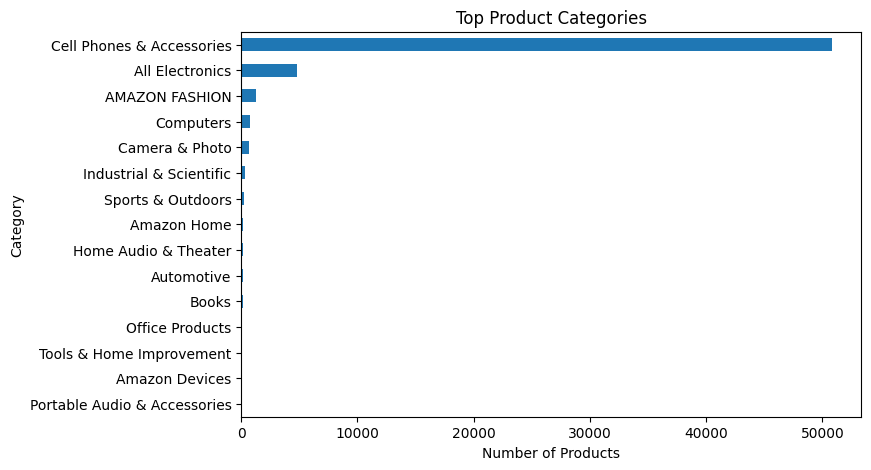

In [7]:
category_counts.sort_values().plot(
    kind="barh",
    figsize=(8, 5)
)

plt.xlabel("Number of Products")
plt.ylabel("Category")
plt.title("Top Product Categories")
plt.show()

### Product Ratings

The distribution of average product ratings is examined to understand the rating characteristics of the filtered product dataset.

In [8]:
products["average_rating"].describe()

count    60889.000000
mean         4.204756
std          0.354362
min          1.000000
25%          4.000000
50%          4.300000
75%          4.500000
max          5.000000
Name: average_rating, dtype: float64

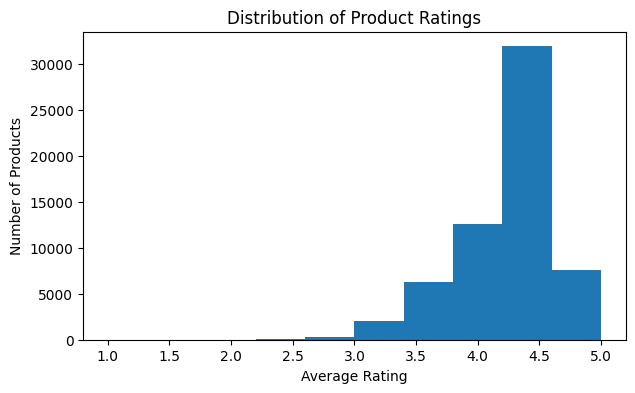

In [9]:
products["average_rating"].plot(
    kind="hist",
    bins=10,
    figsize=(7, 4)
)

plt.xlabel("Average Rating")
plt.ylabel("Number of Products")
plt.title("Distribution of Product Ratings")
plt.show()

## 3. Product-Review Relationship and Filtering

The number of reviews associated with each product is examined before applying the product filtering criterion.

In [10]:
products["review_count"].describe(
    percentiles=[0.10, 0.25, 0.50, 0.75, 0.90, 0.95]
)

count    60889.000000
mean       242.821314
std        667.482980
min         50.000000
10%         56.000000
25%         68.000000
50%        105.000000
75%        203.000000
90%        442.000000
95%        764.600000
max      43237.000000
Name: review_count, dtype: float64

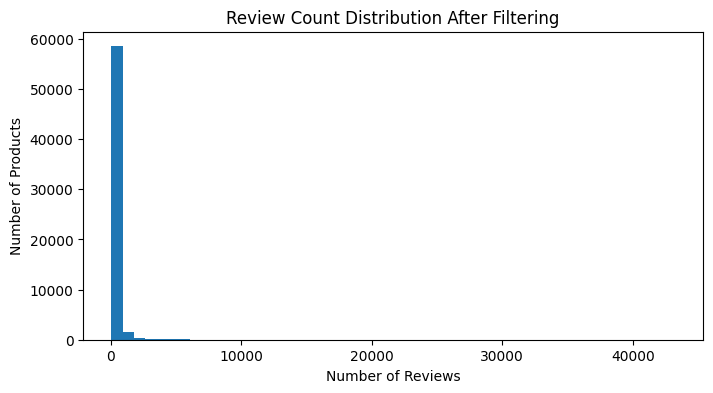

In [11]:
products["review_count"].plot(
    kind="hist",
    bins=50,
    figsize=(8, 4)
)

plt.xlabel("Number of Reviews")
plt.ylabel("Number of Products")
plt.title("Review Count Distribution After Filtering")
plt.show()

### Representative Review Selection

Products with at least 50 reviews were retained to provide sufficient review evidence for product-level retrieval and recommendation.

Five representative reviews were selected for each retained product. Reviews were prioritized using helpful votes, followed by recency.

## 4. Customer Reviews

Customer reviews provide textual information about product usage and customer experiences. These reviews are later incorporated into the product-level documents used by the RAG system.

In [12]:
reviews.head()

,parent_asin,asin,rating,title,text,helpful_vote,verified_purchase,timestamp,review_rank
0,1060697416,1060697416,1.0,doesn't work for note 4,This does not work for the Samsung galaxy note 4 this is a 2.0 . If you want one for the note 4...,13,True,1427762667000,1
1,1060697416,1060697416,1.0,Scam Do not buy,This product is horrible I would never purchase it again or even recommend. They shipped a diffe...,5,True,1422458483000,2
2,1060697416,1060697416,1.0,Bad choice in HDMI interfaces,I bought two of these specifically because they're advertised for Samsung Galaxy Note 4 but neit...,4,True,1431043545000,3
3,1060697416,1060697416,4.0,Double check your phone compatibility before buying,Working as expected.<br />Connection to power is not mandatory - it works without it.<br />Actua...,2,True,1485189131000,4
4,1060697416,1060697416,1.0,DEAD no communication with my NOTE 4 ---- failed product - Samsung Galaxy Note 4 MHL/Micro-USB...,Giving this unit even one star is overly generous.<br />I could not find a way to give it less...,2,True,1421965740000,5


### Review Length

Review length is examined to understand the amount of textual information available in the selected representative reviews.

In [13]:
reviews["text_length"] = reviews["text"].fillna("").astype(str).str.len()

reviews["text_length"].describe(
    percentiles=[0.10, 0.25, 0.50, 0.75, 0.90]
)

count    304445.000000
mean        522.466485
std         721.120676
min           0.000000
10%          77.000000
25%         164.000000
50%         332.000000
75%         627.000000
90%        1110.000000
max       33535.000000
Name: text_length, dtype: float64

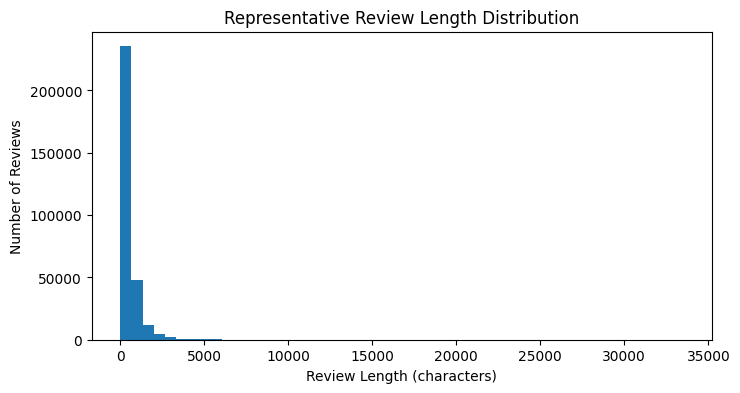

In [14]:
reviews["text_length"].plot(
    kind="hist",
    bins=50,
    figsize=(8, 4)
)

plt.xlabel("Review Length (characters)")
plt.ylabel("Number of Reviews")
plt.title("Representative Review Length Distribution")
plt.show()

## 5. Product Document Construction

A single product-level document is constructed for each retained product by combining product metadata with five representative customer reviews.

This document is used as the textual representation for keyword retrieval and as the source of information provided to the RAG generation stage.

In [15]:
print("Documents:", len(documents))
print("Unique products:", documents["parent_asin"].nunique())

documents["document_length"] = (
    documents["document"]
    .fillna("")
    .astype(str)
    .str.len()
)

documents["document_length"].describe(
    percentiles=[0.10, 0.25, 0.50, 0.75, 0.90, 0.95]
)

Documents: 60889
Unique products: 60889


count    60889.000000
mean      4103.113633
std       2754.074000
min        346.000000
10%       1914.000000
25%       2612.000000
50%       3577.000000
75%       4874.000000
90%       6549.000000
95%       8017.600000
max      97138.000000
Name: document_length, dtype: float64

### Example Product Document

The following example shows how product metadata and customer reviews are combined into a single product document.

In [16]:
print(documents.iloc[0]["document"][:4000])

Product Title: MHL/Micro-USB to HDMI High Speed Adapter! Fast Digital Conversion to HDMI Using The Official MHL 2.0 chipset\nCategory: Cell Phones & Accessories\nFeatures: Converts the Galaxy Note 4 Micro USB Port to an HDMI output for playing back HD videos on a capable HDTV.; The HDTV Universal 11 Pin is the one of the most powerful devices available, capable of recording and playing back video in HD.; With this exclusive certified MHL adaptor, you can playback your videos on your HD-ready TV using a standard HDMI cable.; You'll be amazed at what your HDTV Universal 11 Pin can do with this MHL Adapter while playing multimedia content direct to any HDMI cabled enabled device.; This adaptor features an 11 pin micro USB input so you can plug in your charger and keep your Samsung HDTV Universal 11 Pin fully charged while playing back HD movies or albums.\nDescription: MHL/Micro-USB to HDMI High Speed Adapter! Fast digital conversion to HDMI using the official MHL 2.0 chipset. This Factor

## 6. Embedding Text Construction

A shorter text representation is created separately for semantic retrieval. It contains the most relevant product information while keeping the input compact for the embedding model.

In [17]:
embedding_data[
    ["parent_asin", "title", "embedding_text"]
].head()

,parent_asin,title,embedding_text
0,1060697416,MHL/Micro-USB to HDMI High Speed Adapter! Fast Digital Conversion to HDMI Using The Official MHL...,Title: MHL/Micro-USB to HDMI High Speed Adapter! Fast Digital Conversion to HDMI Using The Offic...
1,120401325X,BY champper Leopard Home Button Sticker for Iphone 4g/4s Ipad2 Ipod (At&t Only) Jc064an + Free S...,Title: BY champper Leopard Home Button Sticker for Iphone 4g/4s Ipad2 Ipod (At&t Only) Jc064an +...
2,1395871035,"Freedi Car Non-slip Dash Grip Pad Mat Dashboard Magic Mounting Pad for Passport 9500ix, Escort, ...","Title: Freedi Car Non-slip Dash Grip Pad Mat Dashboard Magic Mounting Pad for Passport 9500ix, E..."
3,1948701847,Trenro Micro USB to 30 pin Female/Male Charger Adapter compatible with Apple iPhone 4S/iPad /iPod,Title: Trenro Micro USB to 30 pin Female/Male Charger Adapter compatible with Apple iPhone 4S/iP...
4,3056508193,Google Cardboard @ 45mm Focal Length Virtual Reality Google Cardboard with Printed Instructions ...,Title: Google Cardboard @ 45mm Focal Length Virtual Reality Google Cardboard with Printed Instru...


In [18]:
embedding_data["embedding_text_length"] = (
    embedding_data["embedding_text"]
    .fillna("")
    .astype(str)
    .str.len()
)

embedding_data["embedding_text_length"].describe(
    percentiles=[0.10, 0.25, 0.50, 0.75, 0.90, 0.95]
)

count    60889.000000
mean       829.728966
std        122.925693
min        151.000000
10%        645.000000
25%        797.000000
50%        900.000000
75%        900.000000
90%        900.000000
95%        900.000000
max        900.000000
Name: embedding_text_length, dtype: float64

### Example Embedding Text

The following shows the compact representation used to generate semantic embeddings.

In [19]:
print(embedding_data.iloc[0]["embedding_text"])

Title: MHL/Micro-USB to HDMI High Speed Adapter! Fast Digital Conversion to HDMI Using The Official MHL 2.0 chipset\nCategories: Cell Phones & Accessories > Accessories\nFeatures: Converts the Galaxy Note 4 Micro USB Port to an HDMI output for playing back HD videos on a capable HDTV.; The HDTV Universal 11 Pin is the one of the most powerful devices available, capable of recording and playing back video in HD.; With this exclusive certified MHL adaptor, you can playback your\nReviews: This does not work for the Samsung galaxy note  4 this is a 2.0 . If you want one for the note 4 you need the same adapter but a 3.0 This product is horrible I would never purchase it again or even recommend. They shipped a different brand and it is cheaply made did not even work with my tablet.  Scam do not buy!


## 7. Final Dataset Summary

The final processed datasets are validated to ensure that the expected number of products, reviews, and product documents have been created.

In [20]:
summary = pd.DataFrame({
    "Artifact": [
        "Filtered products",
        "Representative reviews",
        "Product documents",
        "Embedding documents"
    ],
    "Rows": [
        len(products),
        len(reviews),
        len(documents),
        len(embedding_data)
    ],
    "Unique Products": [
        products["parent_asin"].nunique(),
        reviews["parent_asin"].nunique(),
        documents["parent_asin"].nunique(),
        embedding_data["parent_asin"].nunique()
    ]
})

summary

,Artifact,Rows,Unique Products
0,Filtered products,60889,60889
1,Representative reviews,304445,60889
2,Product documents,60889,60889
3,Embedding documents,60889,60889


## Summary

- Products with at least 50 reviews were retained for the recommendation system.
- Five representative reviews were selected for each retained product.
- Product metadata and representative reviews were combined into product-level documents.
- A shorter embedding text representation was created for semantic retrieval.
- The final dataset contains 60,889 unique products.